In [84]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('./data/pet_adoption_data.csv')

df = df.drop(columns=['PetID'])


def symulacja_budzetu(y_true, y_proba, budzet=200, koszt_reklamy=10):
    """
    Funkcja oceniająca kampanię na podstawie przewidzianych prawdopodobieństw.
    
    Parametry:
    y_true - rzeczywiste etykiety (1 = szansa na adopcję)
    y_proba - prawdopodobieństwa klasy 1 wyznaczone przez model
    budzet - całkowity budżet (zgodnie z zadaniem 200$)
    koszt_reklamy - koszt jednej reklamy (10$)
    
    Zwraca:
    Oczekiwaną, łączną liczbę zaadoptowanych zwierząt.

    
    """
    if y_proba.ndim == 2:
        y_proba = y_proba[:, 1]

    max_reklam = budzet // koszt_reklamy 
    
    wyniki = pd.DataFrame({'y_true': y_true, 'proba': y_proba})
    wyniki_posortowane = wyniki.sort_values(by='proba', ascending=False)
    
    wybrane = wyniki_posortowane.head(max_reklam)
    
    tp = (wybrane['y_true'] == 1).sum()
    fp = (wybrane['y_true'] == 0).sum()
    
    oczekiwana_liczba_adopcji = (tp * 0.70) + (fp * 0.10)
    
    return oczekiwana_liczba_adopcji
y = df['AdoptionLikelihood']
X = df.drop('AdoptionLikelihood', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [85]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

zmienne_kategoryczne = ['PetType', 'Breed', 'Color', 'Size']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), zmienne_kategoryczne)
    ],
    remainder='passthrough'
)


In [86]:
from sklearn.metrics import make_scorer

def moja_metryka(y_true, y_proba, **kwargs):
    return symulacja_budzetu(y_true, y_proba)

scorer = make_scorer(moja_metryka, needs_proba=True)

In [87]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay

clf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])
clf.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [88]:
param_grid = {
    'model__max_depth': [2, 3, 5, 8, 10, None],
    'model__min_samples_leaf': [1, 5, 10, 20],
    'model__class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(random_state=42))
    ]),
    param_grid,
    cv=cv,
    scoring=scorer,
    n_jobs=-1
)

grid.fit(X_train, y_train)
y_pred = grid.best_estimator_.predict(X_test)
print(grid.best_params_)
print(grid.best_score_)


{'model__class_weight': None, 'model__max_depth': 5, 'model__min_samples_leaf': 1}
13.4


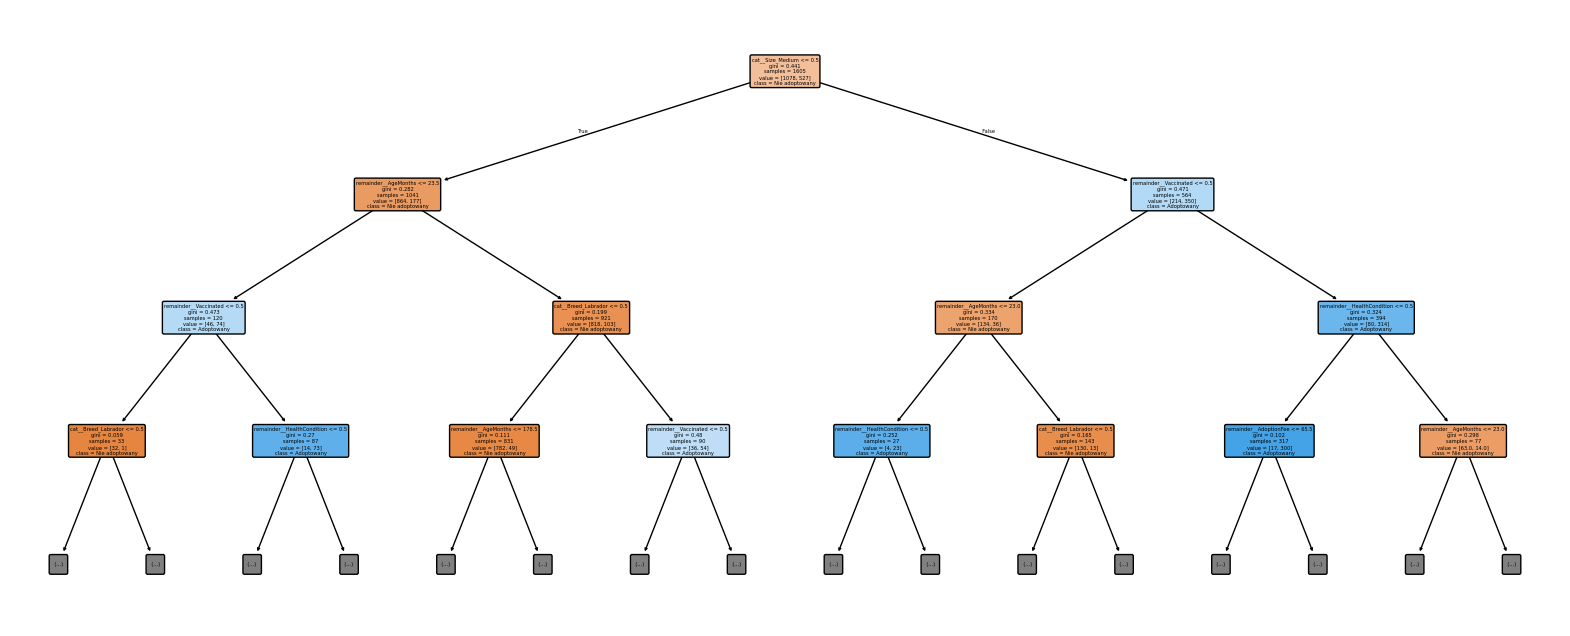

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))
feature_names = grid.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
plot_tree(
    grid.best_estimator_.named_steps['model'],  
    max_depth=3,   
    filled=True,         
    feature_names=feature_names,
    class_names=['Nie adoptowany', 'Adoptowany'],
    rounded=True
)
plt.show()


In [90]:
symulacja_budzetu(y_test, grid.best_estimator_.predict_proba(X_test)[:, 1])

np.float64(12.799999999999999)

In [91]:
y_proba_base = clf.predict_proba(X_test)[:, 1]
y_proba_tuned = grid.best_estimator_.predict_proba(X_test)[:, 1]

print('Bazowe drzewo:', symulacja_budzetu(y_test, y_proba_base))
print('Po tuningu:', symulacja_budzetu(y_test, y_proba_tuned))
print('Baseline losowy:', baseline)

Bazowe drzewo: 11.0
Po tuningu: 12.799999999999999
Baseline losowy: 5.940298507462687


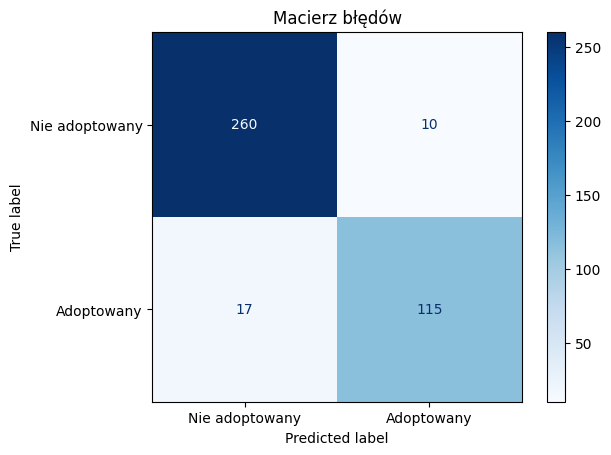

In [92]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    grid.best_estimator_.predict(X_test),
    display_labels=['Nie adoptowany', 'Adoptowany'],
    cmap='Blues'
)
plt.title('Macierz błędów')
plt.show()

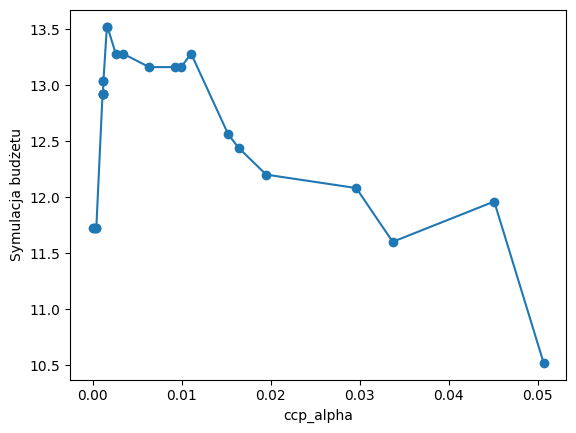

In [ ]:
X_train_transformed = preprocessor.fit_transform(X_train)
path = grid.best_estimator_.named_steps['model'].cost_complexity_pruning_path(X_train_transformed, y_train)
alphas = path.ccp_alphas[:-1]  
scores = []
for alpha in alphas[::max(1, len(alphas)//20)]: 
    clf_pruned = Pipeline([
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(ccp_alpha=alpha, random_state=42))
    ])
    score = cross_val_score(clf_pruned, X_train, y_train, cv=cv, scoring=scorer).mean()
    scores.append((alpha, score))

a, s = zip(*scores)
plt.plot(a, s, marker='o')
plt.xlabel('ccp_alpha')
plt.ylabel('Symulacja budżetu')
plt.show()


In [94]:
import numpy as np
best_alpha = a[np.argmax(s)]
clf_pruned = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42))
])
clf_pruned.fit(X_train, y_train)
y_pred_pruned = clf_pruned.predict(X_test)
print(symulacja_budzetu(y_test, clf_pruned.predict_proba(X_test)[:, 1]))


12.799999999999999


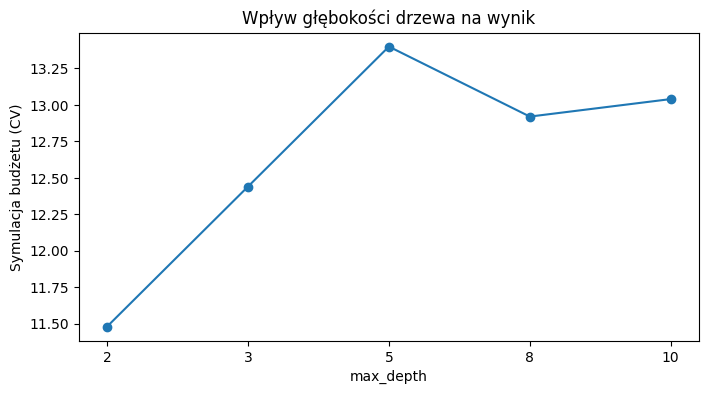

In [95]:
results = pd.DataFrame(grid.cv_results_)
depth_results = results.groupby('param_model__max_depth')['mean_test_score'].max().reset_index()
depth_results['param_model__max_depth'] = depth_results['param_model__max_depth'].astype(str)

plt.figure(figsize=(8, 4))
plt.plot(depth_results['param_model__max_depth'], depth_results['mean_test_score'], marker='o')
plt.xlabel('max_depth')
plt.ylabel('Symulacja budżetu (CV)')
plt.title('Wpływ głębokości drzewa na wynik')
plt.show()


In [ ]:
import joblib


joblib.dump(grid.best_estimator_, 'Tree_shelter_model.pkl')
print('Zapisano model do pliku Tree_shelter_model.pkl')

Zapisano model do pliku Tree_shelter_model.pkl
